In [0]:
patients_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/Volumes/ey_data/default/data/patients.csv")

In [0]:
doctors_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/Volumes/ey_data/default/data/doctors.csv")

In [0]:
appointments_df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/Volumes/ey_data/default/data/appointments.csv")

In [0]:
preferences_df = spark.read \
    .option("multiLine", "true") \
    .json("/Volumes/ey_data/default/data/patient_preferences.json")

In [0]:
display(dbutils.fs.ls("/Volumes/ey_data/default/data"))

path,name,size,modificationTime
dbfs:/Volumes/ey_data/default/data/appointments.csv,appointments.csv,624,1782129592000
dbfs:/Volumes/ey_data/default/data/doctors.csv,doctors.csv,300,1782129592000
dbfs:/Volumes/ey_data/default/data/patient_preferences.json,patient_preferences.json,562,1782129592000
dbfs:/Volumes/ey_data/default/data/patients.csv,patients.csv,475,1782129592000


In [0]:
patients_df.printSchema()

doctors_df.printSchema()

appointments_df.printSchema()

preferences_df.printSchema()

root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospita

In [0]:
patient_pref = patients_df.join(
    preferences_flat,
    on="patient_id",
    how="left"
)

display(patient_pref)

patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null
P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null
P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com


In [0]:
patients_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_patients")

In [0]:
doctors_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_doctors")

In [0]:
appointments_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_appointments")

In [0]:
preferences_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("bronze_preferences")

In [0]:
patients_df = patients_df.fillna("Unknown")

doctors_df = doctors_df.fillna("Unknown")

appointments_df = appointments_df.fillna({
    "bill_amount": 0,
    "status": "Pending"
})

In [0]:
from pyspark.sql.functions import col
preferences_flat = preferences_df.select(
    "patient_id",
    "preferred_hospital",
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)

display(preferences_flat)

patient_id,preferred_hospital,phone,email
P101,Apollo Hospital,9876500011,rahul@mail.com
P102,Yashoda Hospital,9876500012,priya@mail.com
P104,Care Hospital,9876500014,sneha@mail.com
P108,Apollo Hospital,9876500018,meera@mail.com


In [0]:
appointment_patient = appointments_df.join(
    patients_df,
    "patient_id",
    "inner"
)

display(appointment_patient)

patient_id,appointment_id,doctor_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status
P101,A1001,D101,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,A1002,D102,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,A1003,D103,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,A1004,D104,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,A1005,D105,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,A1006,D106,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,A1007,D101,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,A1008,D103,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active
P101,A1009,D106,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P104,A1010,D104,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active


In [0]:
appointment_doctor = appointment_patient.join(
    doctors_df,
    "doctor_id",
    "inner"
)

display(appointment_doctor)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,city,consultation_fee
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500


In [0]:
healthcare_df = appointment_doctor

In [0]:
healthcare_df = healthcare_df.withColumn(
    "appointment_month",
    month("appointment_date")
)

display(healthcare_df)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,city,consultation_fee,appointment_month
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,6
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,6
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,6
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,6
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,6
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,6
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,6
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,6


In [0]:
healthcare_df = healthcare_df.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)

display(healthcare_df)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,city,consultation_fee,appointment_month,patient_age_group
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6,Adult
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,6,Young
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,6,Adult
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,6,Adult
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,6,Senior
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,6,Adult
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6,Young
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,6,Adult
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,6,Adult
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,6,Adult


In [0]:
appointment_patient = appointments_df.join(
    patients_df,
    "patient_id",
    "inner"
)

healthcare_df = appointment_patient.join(
    doctors_new,
    "doctor_id",
    "inner"
)

In [0]:
from pyspark.sql.functions import *

healthcare_df = healthcare_df.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
)

display(healthcare_df)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
patient_pref.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_patients")

In [0]:
doctors_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_doctors")

In [0]:
appointments_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_appointments")

In [0]:
doctors_new = doctors_df.withColumnRenamed("city", "doctor_city")

In [0]:
healthcare_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_healthcare")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6768739603093155>, line 4
      1 healthcare_df.write \
      2 .format("delta") \
      3 .mode("overwrite") \
----> 4 .saveAsTable("silver_healthcare")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/readwriter.py:737, in DataFrameWriter.saveAsTable(self, name, format, mode, partitionBy, **options)
    735 self._write.table_name = name
    736 self._write.table_save_method = "save_as_table"
--> 737 _, _, ei = self._spark.client.execute_command(
    738     self._write.command(self._spark.client), self._write.observations
    739 )
    740 self._callback(ei)

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_context.user_id = self._user_id
   

In [0]:
display(spark.sql("SHOW TABLES"))

database,tableName,isTemporary
default,bronze_appointments,false
default,bronze_doctors,false
default,bronze_patients,false
default,bronze_preferences,false
default,silver_appointments,false
default,silver_doctors,false
default,silver_healthcare,false
default,silver_patients,false
,healthcare,true


In [0]:
healthcare_df.createOrReplaceTempView("healthcare")

In [0]:
healthcare_df.show()

In [0]:
spark.sql("""
SELECT SUM(final_bill) AS Total_Revenue
FROM healthcare
""").show()

+-------------+
|Total_Revenue|
+-------------+
|        69200|
+-------------+



In [0]:
spark.sql("""
SELECT
department,
SUM(final_bill) AS Revenue
FROM healthcare
GROUP BY department
ORDER BY Revenue DESC
""").show()

+-----------+-------+
| department|Revenue|
+-----------+-------+
| Cardiology|  33000|
|Orthopedics|  21500|
|Dermatology|   6500|
|  Neurology|   5500|
| Pediatrics|   2700|
+-----------+-------+



In [0]:
spark.sql("""
SELECT
city,
SUM(final_bill) AS Revenue
FROM healthcare
GROUP BY city
ORDER BY Revenue DESC
""").show()

+---------+-------+
|     city|Revenue|
+---------+-------+
|Hyderabad|  23000|
|    Delhi|  21500|
|     Pune|  10000|
|Bangalore|   5500|
|    Kochi|   3500|
|   Mumbai|   3000|
|  Chennai|   2700|
+---------+-------+



In [0]:
spark.sql("""
SELECT *
FROM healthcare
WHERE status='Completed'
""").show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnatak

In [0]:
spark.sql("""
SELECT
patient_name,
SUM(final_bill) AS Total_Bill
FROM healthcare
GROUP BY patient_name
ORDER BY Total_Bill DESC
LIMIT 5
""").show()

+------------+----------+
|patient_name|Total_Bill|
+------------+----------+
| Sneha Patel|     21500|
|Rahul Sharma|     16000|
|  Neha Singh|     10000|
| Arjun Verma|      7000|
| Priya Reddy|      5500|
+------------+----------+



In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *

In [0]:
doctor_revenue = healthcare_df.groupBy(
    "doctor_name"
).agg(
    sum("final_bill").alias("Revenue")
)

windowSpec = Window.orderBy(desc("Revenue"))

doctor_rank = doctor_revenue.withColumn(
    "Rank",
    rank().over(windowSpec)
)

display(doctor_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


doctor_name,Revenue,Rank
Dr. Suresh,21500,1
Dr. Kiran,19500,2
Dr. Ramesh,13500,3
Dr. Anita,6500,4
Dr. Priya,5500,5
Dr. Meera,2700,6


In [0]:
department_revenue = healthcare_df.groupBy(
    "department"
).agg(
    sum("final_bill").alias("Revenue")
)

windowSpec = Window.orderBy(desc("Revenue"))

department_rank = department_revenue.withColumn(
    "Rank",
    rank().over(windowSpec)
)

display(department_rank)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


department,Revenue,Rank
Cardiology,33000,1
Orthopedics,21500,2
Dermatology,6500,3
Neurology,5500,4
Pediatrics,2700,5


In [0]:
patient_bill = healthcare_df.groupBy(
    "patient_name"
).agg(
    sum("final_bill").alias("Total_Bill")
)

windowSpec = Window.orderBy(desc("Total_Bill"))

top_patients = patient_bill.withColumn(
    "Rank",
    dense_rank().over(windowSpec)
).filter(col("Rank") <= 3)

display(top_patients)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


patient_name,Total_Bill,Rank
Sneha Patel,21500,1
Rahul Sharma,16000,2
Neha Singh,10000,3


In [0]:
doctor_dept = healthcare_df.groupBy(
    "department",
    "doctor_name"
).agg(
    sum("final_bill").alias("Revenue")
)

windowSpec = Window.partitionBy(
    "department"
).orderBy(desc("Revenue"))

top_doctor = doctor_dept.withColumn(
    "Rank",
    row_number().over(windowSpec)
).filter(col("Rank")==1)

display(top_doctor)

department,doctor_name,Revenue,Rank
Cardiology,Dr. Kiran,19500,1
Dermatology,Dr. Anita,6500,1
Neurology,Dr. Priya,5500,1
Orthopedics,Dr. Suresh,21500,1
Pediatrics,Dr. Meera,2700,1


In [0]:
daily_revenue = healthcare_df.groupBy(
    "appointment_date"
).agg(
    sum("final_bill").alias("Revenue")
)

windowSpec = Window.orderBy("appointment_date")

running_revenue = daily_revenue.withColumn(
    "Running_Revenue",
    sum("Revenue").over(windowSpec)
)

display(running_revenue)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


appointment_date,Revenue,Running_Revenue
2026-06-01,12000,12000
2026-06-02,17500,29500
2026-06-03,12700,42200
2026-06-04,10500,52700
2026-06-05,16500,69200


In [0]:
healthcare_df.write \
.format("delta") \
.mode("overwrite") \
.save("/tmp/healthcare_delta")

In [0]:
delta_df = spark.read \
.format("delta") \
.load("/tmp/healthcare_delta")

display(delta_df)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
healthcare_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("healthcare_master")

In [0]:
display(spark.sql("SELECT * FROM healthcare_master"))

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
%sql
CREATE TABLE healthcare_sql
USING DELTA
AS
SELECT *
FROM healthcare_master;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM healthcare_sql;

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
%sql DESCRIBE HISTORY healthcare_master;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T12:31:12.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1903386514513375),71884f5d-c73b-48c4-819f-a62f522ea7ff,0622-120128-6iayozen-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5735)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
version0 = spark.read \
.format("delta") \
.option("versionAsOf",0) \
.table("healthcare_master")

display(version0)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
latest = spark.read \
.format("delta") \
.table("healthcare_master")

display(latest)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
updated_patients = [
("P101","Hyderabad","Inactive"),
("P105","Chennai","Inactive"),
("P108","Kochi","Inactive")
]

columns = ["patient_id","city","insurance_status"]

updated_df = spark.createDataFrame(updated_patients,columns)

display(updated_df)

patient_id,city,insurance_status
P101,Hyderabad,Inactive
P105,Chennai,Inactive
P108,Kochi,Inactive


In [0]:
updated_df.createOrReplaceTempView("patient_updates")

In [0]:
spark.sql("""MERGE INTO healthcare_master target
USING patient_updates source
ON target.patient_id = source.patient_id

WHEN MATCHED THEN
UPDATE SET
target.city = source.city,
target.insurance_status = source.insurance_status""")

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql DESCRIBE HISTORY healthcare_master;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T12:34:38.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(1903386514513375),98d928ec-8037-467d-8c7e-472c2166c9a1,0622-120128-6iayozen-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 2, numRemovedBytes -> 10883, p25FileSize -> 5821, numDeletionVectorsRemoved -> 1, minFileSize -> 5821, numAddedFiles -> 1, maxFileSize -> 5821, p75FileSize -> 5821, p50FileSize -> 5821, numAddedBytes -> 5821)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T12:34:36.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(patient_id#23874 = patient_id#23726)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [])",null,List(1903386514513375),98d928ec-8037-467d-8c7e-472c2166c9a1,0622-120128-6iayozen-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 5148, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 4, executionTimeMs -> 4002, materializeSourceTimeMs -> 192, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1928, numTargetRowsUpdated -> 4, numOutputRows -> 4, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 3, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1812)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T12:31:12.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1903386514513375),71884f5d-c73b-48c4-819f-a62f522ea7ff,0622-120128-6iayozen-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5735)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql OPTIMIZE healthcare_master;

path,metrics
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/22aff5cb-dfe9-42e6-bd9b-4c2827b53a13,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, null, null, 0, 0, 1, 1, true, 0, 0, 1782131740968, 1782131741426, 8, 0, null, List(0, 0), null, 18, 18, 0, 0, null, null)"


In [0]:
%sql
OPTIMIZE healthcare_master
ZORDER BY(patient_id);

path,metrics
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/22aff5cb-dfe9-42e6-bd9b-4c2827b53a13,"List(0, 0, List(null, null, 0.0, 0, 0), List(null, null, 0.0, 0, 0), 0, List(minCubeSize(107374182400), List(0, 0), List(1, 5821), 0, List(0, 0), 0, null), null, 0, 0, 1, 1, false, 0, 0, 1782131756689, 1782131757172, 8, 0, null, List(0, 0), null, 18, 18, 0, 0, null, null)"


In [0]:
%sql
VACUUM healthcare_master;

path
abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/__unitystorage/catalogs/2ac6a545-2d98-44db-81d8-6475f1e7de87/tables/22aff5cb-dfe9-42e6-bd9b-4c2827b53a13


In [0]:
%sql
DESCRIBE HISTORY healthcare_master;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
4,2026-06-22T12:36:17.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM END,Map(status -> COMPLETED),null,List(1903386514513375),07d26fb8-4eaa-4170-9ad8-b29211cd3c0e,0622-120128-6iayozen-v2n,3,SnapshotIsolation,true,"Map(numDeletedFiles -> 0, numVacuumedDirectories -> 1)",null,Databricks-Runtime/18.2.x-photon-scala2.13
3,2026-06-22T12:36:16.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,VACUUM START,"Map(retentionCheckEnabled -> true, defaultRetentionMillis -> 604800000)",null,List(1903386514513375),07d26fb8-4eaa-4170-9ad8-b29211cd3c0e,0622-120128-6iayozen-v2n,2,SnapshotIsolation,true,"Map(numFilesToDelete -> 0, sizeOfDataToDelete -> 0)",null,Databricks-Runtime/18.2.x-photon-scala2.13
2,2026-06-22T12:34:38.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(1903386514513375),98d928ec-8037-467d-8c7e-472c2166c9a1,0622-120128-6iayozen-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 2, numRemovedBytes -> 10883, p25FileSize -> 5821, numDeletionVectorsRemoved -> 1, minFileSize -> 5821, numAddedFiles -> 1, maxFileSize -> 5821, p75FileSize -> 5821, p50FileSize -> 5821, numAddedBytes -> 5821)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T12:34:36.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(patient_id#23874 = patient_id#23726)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [])",null,List(1903386514513375),98d928ec-8037-467d-8c7e-472c2166c9a1,0622-120128-6iayozen-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 1, numTargetBytesAdded -> 5148, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 4, executionTimeMs -> 4002, materializeSourceTimeMs -> 192, numTargetRowsInserted -> 0, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1928, numTargetRowsUpdated -> 4, numOutputRows -> 4, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 3, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1812)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T12:31:12.000Z,145573088054222,azuser7215_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(1903386514513375),71884f5d-c73b-48c4-819f-a62f522ea7ff,0622-120128-6iayozen-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5735)",null,Databricks-Runtime/18.2.x-photon-scala2.13


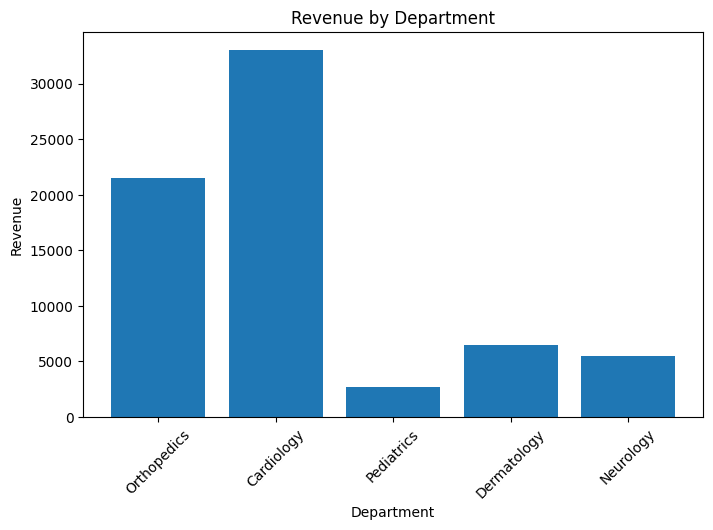

In [0]:
import matplotlib.pyplot as plt
dept_df = healthcare_df.groupBy("department") \
    .sum("final_bill") \
    .withColumnRenamed("sum(final_bill)", "Revenue")

pdf = dept_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["department"], pdf["Revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

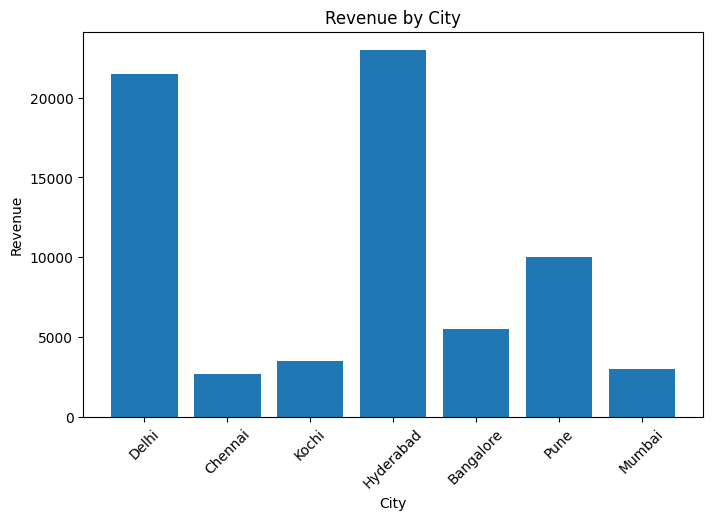

In [0]:
city_df = healthcare_df.groupBy("city") \
    .sum("final_bill") \
    .withColumnRenamed("sum(final_bill)", "Revenue")

pdf = city_df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["city"], pdf["Revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

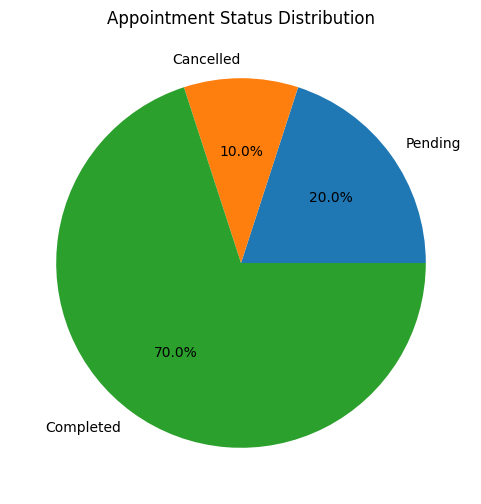

In [0]:
status_df = healthcare_df.groupBy("status").count()

pdf = status_df.toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    pdf["count"],
    labels=pdf["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

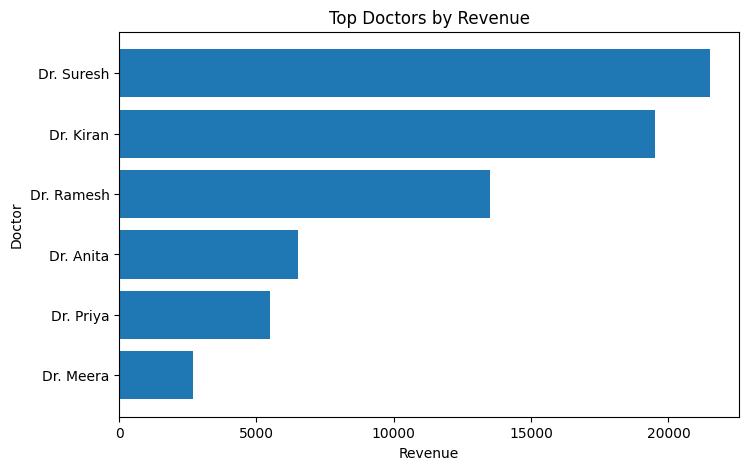

In [0]:
doctor_df = healthcare_df.groupBy("doctor_name") \
    .sum("final_bill") \
    .withColumnRenamed("sum(final_bill)", "Revenue")

pdf = doctor_df.toPandas()

pdf = pdf.sort_values("Revenue")

plt.figure(figsize=(8,5))
plt.barh(pdf["doctor_name"], pdf["Revenue"])
plt.title("Top Doctors by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Doctor")
plt.show()

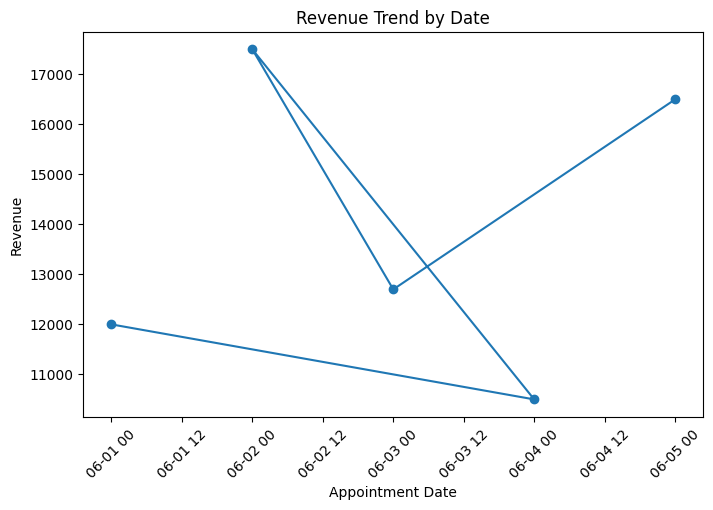

In [0]:
trend_df = healthcare_df.groupBy("appointment_date") \
    .sum("final_bill") \
    .withColumnRenamed("sum(final_bill)", "Revenue")

pdf = trend_df.toPandas()

plt.figure(figsize=(8,5))
plt.plot(pdf["appointment_date"], pdf["Revenue"], marker="o")
plt.title("Revenue Trend by Date")
plt.xlabel("Appointment Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [0]:
healthcare_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("managed_healthcare")

In [0]:
display(spark.sql("SELECT * FROM managed_healthcare"))

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
healthcare_df.write \
.format("delta") \
.mode("overwrite") \
.save("/Volumes/ey_data/default/data/external_healthcare")

In [0]:
healthcare_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/external_healthcare")

In [0]:
%sql
CREATE TABLE external_healthcare
USING DELTA
LOCATION 'abfss://unity-catalog-storage@dbstoraged3qaeocrzs7hk.dfs.core.windows.net/7405605955177719/external_healthcare';

In [0]:
%sql
SELECT * FROM external_healthcare;

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee,final_bill
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,6500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000,5500
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000,3000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,14500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200,2700
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000,10000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500,7000
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000,3500
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000,9500
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500,7000


In [0]:
healthcare_df.createOrReplaceTempView("healthcare_temp")
spark.sql("""
SELECT *
FROM healthcare_temp
""").show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnatak

In [0]:
healthcare_df.createOrReplaceTempView("healthcare_global")